# Analyze Context-Stratified Outside Shot Value

This notebook tests whether the observed slot-support patterns from Notebook 07 differ by shot context.

The analysis cohort is restricted to:

- true 5v5
- outside-origin shots
- offensive-zone origin
- origin tracking available
- no tracking error flag

The context labels were created in Notebook 08:

- offensive-zone entry within 5 seconds proxy
- offensive-zone faceoff within 5 seconds
- settled offensive-zone possession proxy
- other / unknown

The main question is not whether more observed slot support is generally better.

The main question is whether different contexts reveal useful thresholds or diminishing returns, especially:

- whether the goal rate peaks at 2 observed attackers
- whether the 3+ bin drops in goal rate
- whether 3+ shifts value toward deflections rather than follow-ups
- whether the largest marginal jump is 0→1 or 1→2

## 1. Setup

Load libraries, define paths, and configure display options.

In [1]:
# Import libraries used for context-stratified analysis

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Define project paths for processed data and optional figures

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed data exists:", DATA_PROCESSED.exists())
print("Figures dir:", FIGURES_DIR)

Project root: c:\Users\rinal\hockey-analytics\outside-shot-value
Processed data exists: True
Figures dir: c:\Users\rinal\hockey-analytics\outside-shot-value\figures


In [3]:
# Configure pandas display options for readable notebook tables

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:0.6f}")

## 2. Load Context-Labeled Chain Dataset

Load the context-labeled origin-shot chain dataset created in Notebook 08.

This file should contain one row per origin-shot chain, with strength labels, observed tracking slot-support features, offensive-zone origin flags, and shot-context labels.

In [4]:
# Load context-labeled origin-shot chain dataset

df = pd.read_parquet(DATA_PROCESSED / "origin_shot_sequences_context_labeled.parquet")

print("df:", df.shape)
df.head()

df: (48673, 111)


,chain_id,game_id,period,sequence_id,team_id,raw_first_chance_team_id,n_team_id_overrides_for_chain,chain_start_time,chain_end_time,chain_duration_seconds,n_chances_in_chain,anchor_origin_event_id,anchor_origin_period_time,anchor_origin_location,anchor_first_chance_event_id,anchor_first_chance_time,anchor_first_event_type,anchor_first_chance_location,first_evaluated_chance_event_id,first_evaluated_chance_time,first_evaluated_event_type,first_evaluated_location,first_evaluated_xg,chain_max_xg,chain_sum_xg,has_deflection,n_deflections,first_deflection_event_id,first_deflection_time,deflection_max_xg,deflection_sum_xg,has_followup_chance,n_followup_chances,first_followup_event_id,first_followup_time,followup_max_xg,followup_sum_xg,chain_goal,chain_goal_event_id,chain_goal_time,chain_goal_player_id,chain_goal_player_name,chain_any_goal_within_2s_flag,origin_tracking_rows,origin_identified_tracking_players,origin_missing_tracking_player_rows,origin_attacker_skaters_tracked,origin_defender_skaters_tracked,observed_origin_attackers_in_slot,observed_origin_defenders_in_slot,origin_goalies_tracked,origin_shooter_tracked,origin_tracking_available,origin_tracking_error_flag,origin_tracking_completeness_bucket,home_team,away_team,home_team_id,away_team_id,team_side,period_time_start,game_stint,period_time_end,n_home_skaters,n_away_skaters,is_home_net_empty,is_away_net_empty,home_score,away_score,origin_time_within_stint,is_5v5,team_n_skaters,opponent_n_skaters,team_net_empty,opponent_net_empty,raw_anchor_origin_period_time,anchor_origin_event_type_raw,anchor_origin_event_team,anchor_origin_x_adj,anchor_origin_y_adj,is_offensive_zone_origin,is_behind_offensive_blue_line_origin,chain_team_name,prior_faceoff_event_id,prior_faceoff_time,prior_faceoff_team,prior_faceoff_x_adj_for_event_team,prior_faceoff_y_adj_for_event_team,seconds_since_prior_faceoff,prior_faceoff_x_adj_for_chain_team,prior_faceoff_y_adj_for_chain_team,has_prior_faceoff_in_sequence,prior_faceoff_within_5s,prior_faceoff_in_offensive_zone_for_chain,oz_faceoff_context_5s,first_same_team_event_time_in_sequence,n_same_team_events_in_sequence,seconds_since_first_same_team_event_in_sequence,early_same_team_sequence_5s_diagnostic,settled_sequence_gt5s_diagnostic,entry_proxy_event_id,entry_proxy_time,entry_proxy_event_type,entry_proxy_x_adj_for_chain_team,entry_proxy_y_adj_for_chain_team,seconds_since_entry_proxy,has_entry_proxy_in_sequence,entry_proxy_within_5s,oz_entry_context_5s_proxy,settled_offensive_zone_context_proxy,shot_context
0,00b0366a-95c6-5250-2dae-e3dd5c4198bc_p1_s11_td...,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,11,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,0,591.730000,591.730000,0.000000,1,565,591.730000,outside,565,591.730000,shot,outside,565,591.730000,shot,outside,0.040997,0.040997,0.040997,False,0,<NA>,NaN,0.000000,0.000000,False,0,<NA>,NaN,0.000000,0.000000,False,<NA>,NaN,NaN,NaN,False,8,7,1,4,3,1,2,0,True,True,False,partial_observed,GR,CLE,6cac12e2-0546-2c1a-689f-ab26d8a6355a,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,away,589.030000,64.000000,605.030000,4.000000,4.000000,False,False,1.000000,1.000000,True,False,4.000000,4.000000,False,False,591.730000000,shot,CLE,32.889107,25.397057,True,False,CLE,558.000000,589.030000,CLE,69.104380,21.376137,2.700000,69.104380,21.376137,True,True,True,True,589.030000,20,2.700000,True,False,560.000000,589.100000,pass,69.100876,23.385292,2.630000,True,True,True,False,oz_faceoff_5s
1,00b0366a-95c6-5250-2dae-e3dd5c4198bc_p1_s12_t6...,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,12,6cac12e2-0546-2c1a-689f-ab26d8a6355a,6cac12e2-0546-2c1a-689f-ab26d8a6355a,0,722.400000,722.400000,0.000000,1,687,722.400000,outside,687,722.400000,shot,outside,687,722.400000,shot,outside,0.015540,0.015540,0.015540,False,0,<NA>,NaN,0.000000,0.000000,False,0,<NA>,NaN,0.000000,0.000000,False,<NA>,NaN,NaN,NaN,False,10,7,3,4,3,1,2,0,True,True,False,partial_observed,GR,CLE,6cac12e2-0546-2c1a-689f-ab26d8a6355a,d7ff41e7-8310-f2ab-3c79-6ad3d1f

In [5]:
# Inspect available columns before defining analysis cohorts

df.columns.tolist()

['chain_id',
 'game_id',
 'period',
 'sequence_id',
 'team_id',
 'raw_first_chance_team_id',
 'n_team_id_overrides_for_chain',
 'chain_start_time',
 'chain_end_time',
 'chain_duration_seconds',
 'n_chances_in_chain',
 'anchor_origin_event_id',
 'anchor_origin_period_time',
 'anchor_origin_location',
 'anchor_first_chance_event_id',
 'anchor_first_chance_time',
 'anchor_first_event_type',
 'anchor_first_chance_location',
 'first_evaluated_chance_event_id',
 'first_evaluated_chance_time',
 'first_evaluated_event_type',
 'first_evaluated_location',
 'first_evaluated_xg',
 'chain_max_xg',
 'chain_sum_xg',
 'has_deflection',
 'n_deflections',
 'first_deflection_event_id',
 'first_deflection_time',
 'deflection_max_xg',
 'deflection_sum_xg',
 'has_followup_chance',
 'n_followup_chances',
 'first_followup_event_id',
 'first_followup_time',
 'followup_max_xg',
 'followup_sum_xg',
 'chain_goal',
 'chain_goal_event_id',
 'chain_goal_time',
 'chain_goal_player_id',
 'chain_goal_player_name',
 'ch

## 3. Validate Required Columns

Confirm that all required fields are present before analysis.

This prevents accidentally analyzing an older parquet file or a stale intermediate dataset.

In [6]:
# Check that all fields required for context-stratified analysis are present

required_columns = [
    "chain_id",
    "game_id",
    "period",
    "sequence_id",
    "team_id",
    "is_5v5",
    "anchor_origin_location",
    "is_offensive_zone_origin",
    "is_behind_offensive_blue_line_origin",
    "shot_context",
    "first_evaluated_xg",
    "chain_max_xg",
    "followup_max_xg",
    "has_followup_chance",
    "has_deflection",
    "chain_goal",
    "origin_tracking_available",
    "origin_tracking_error_flag",
    "origin_tracking_completeness_bucket",
    "observed_origin_attackers_in_slot",
    "observed_origin_defenders_in_slot",
    "origin_attacker_skaters_tracked",
    "origin_defender_skaters_tracked",
    "seconds_since_prior_faceoff",
    "seconds_since_entry_proxy",
]

missing_required_columns = [c for c in required_columns if c not in df.columns]

missing_required_columns

[]

In [7]:
# Validate one-row-per-chain structure and core label availability

initial_validation = {
    "rows": len(df),
    "unique_chain_ids": df["chain_id"].nunique(),
    "duplicate_chain_ids": df.duplicated("chain_id").sum(),
    "missing_is_5v5": df["is_5v5"].isna().sum(),
    "missing_shot_context": df["shot_context"].isna().sum(),
    "missing_chain_max_xg": df["chain_max_xg"].isna().sum(),
    "tracking_available_counts": df["origin_tracking_available"].value_counts(dropna=False).to_dict(),
    "tracking_error_flag_counts": df["origin_tracking_error_flag"].value_counts(dropna=False).to_dict(),
    "shot_context_counts": df["shot_context"].value_counts(dropna=False).to_dict(),
}

initial_validation

{'rows': 48673,
 'unique_chain_ids': 48673,
 'duplicate_chain_ids': np.int64(0),
 'missing_is_5v5': np.int64(0),
 'missing_shot_context': np.int64(0),
 'missing_chain_max_xg': np.int64(0),
 'tracking_available_counts': {True: 45343, False: 3330},
 'tracking_error_flag_counts': {False: 48650, True: 23},
 'shot_context_counts': {'settled_offensive_zone_proxy': 35038,
  'oz_entry_5s_proxy': 8894,
  'oz_faceoff_5s': 3615,
  'other_or_unknown': 1126}}

## 4. Define Analysis Cohort

The main analysis cohort is the same clean cohort established in Notebook 07, now with context labels added:

- 5v5
- outside-origin
- offensive-zone origin
- tracking available
- no tracking error flag

The `other_or_unknown` context is kept in the denominator table but will usually be excluded from context-specific interpretation because it is too small.

In [8]:
# Create readable boolean masks for the context-stratified analysis cohort

is_5v5 = df["is_5v5"]
is_outside_origin = df["anchor_origin_location"].eq("outside")
is_offensive_zone_origin = df["is_offensive_zone_origin"]
has_tracking_available = df["origin_tracking_available"]
has_no_tracking_error = ~df["origin_tracking_error_flag"]

analysis_mask = (
    is_5v5
    & is_outside_origin
    & is_offensive_zone_origin
    & has_tracking_available
    & has_no_tracking_error
)

analysis = df[analysis_mask].copy()

print("analysis:", analysis.shape)
analysis.head()

analysis: (21536, 111)


,chain_id,game_id,period,sequence_id,team_id,raw_first_chance_team_id,n_team_id_overrides_for_chain,chain_start_time,chain_end_time,chain_duration_seconds,n_chances_in_chain,anchor_origin_event_id,anchor_origin_period_time,anchor_origin_location,anchor_first_chance_event_id,anchor_first_chance_time,anchor_first_event_type,anchor_first_chance_location,first_evaluated_chance_event_id,first_evaluated_chance_time,first_evaluated_event_type,first_evaluated_location,first_evaluated_xg,chain_max_xg,chain_sum_xg,has_deflection,n_deflections,first_deflection_event_id,first_deflection_time,deflection_max_xg,deflection_sum_xg,has_followup_chance,n_followup_chances,first_followup_event_id,first_followup_time,followup_max_xg,followup_sum_xg,chain_goal,chain_goal_event_id,chain_goal_time,chain_goal_player_id,chain_goal_player_name,chain_any_goal_within_2s_flag,origin_tracking_rows,origin_identified_tracking_players,origin_missing_tracking_player_rows,origin_attacker_skaters_tracked,origin_defender_skaters_tracked,observed_origin_attackers_in_slot,observed_origin_defenders_in_slot,origin_goalies_tracked,origin_shooter_tracked,origin_tracking_available,origin_tracking_error_flag,origin_tracking_completeness_bucket,home_team,away_team,home_team_id,away_team_id,team_side,period_time_start,game_stint,period_time_end,n_home_skaters,n_away_skaters,is_home_net_empty,is_away_net_empty,home_score,away_score,origin_time_within_stint,is_5v5,team_n_skaters,opponent_n_skaters,team_net_empty,opponent_net_empty,raw_anchor_origin_period_time,anchor_origin_event_type_raw,anchor_origin_event_team,anchor_origin_x_adj,anchor_origin_y_adj,is_offensive_zone_origin,is_behind_offensive_blue_line_origin,chain_team_name,prior_faceoff_event_id,prior_faceoff_time,prior_faceoff_team,prior_faceoff_x_adj_for_event_team,prior_faceoff_y_adj_for_event_team,seconds_since_prior_faceoff,prior_faceoff_x_adj_for_chain_team,prior_faceoff_y_adj_for_chain_team,has_prior_faceoff_in_sequence,prior_faceoff_within_5s,prior_faceoff_in_offensive_zone_for_chain,oz_faceoff_context_5s,first_same_team_event_time_in_sequence,n_same_team_events_in_sequence,seconds_since_first_same_team_event_in_sequence,early_same_team_sequence_5s_diagnostic,settled_sequence_gt5s_diagnostic,entry_proxy_event_id,entry_proxy_time,entry_proxy_event_type,entry_proxy_x_adj_for_chain_team,entry_proxy_y_adj_for_chain_team,seconds_since_entry_proxy,has_entry_proxy_in_sequence,entry_proxy_within_5s,oz_entry_context_5s_proxy,settled_offensive_zone_context_proxy,shot_context
1,00b0366a-95c6-5250-2dae-e3dd5c4198bc_p1_s12_t6...,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,12,6cac12e2-0546-2c1a-689f-ab26d8a6355a,6cac12e2-0546-2c1a-689f-ab26d8a6355a,0,722.400000,722.400000,0.000000,1,687,722.400000,outside,687,722.400000,shot,outside,687,722.400000,shot,outside,0.015540,0.015540,0.015540,False,0,<NA>,NaN,0.000000,0.000000,False,0,<NA>,NaN,0.000000,0.000000,False,<NA>,NaN,NaN,NaN,False,10,7,3,4,3,1,2,0,True,True,False,partial_observed,GR,CLE,6cac12e2-0546-2c1a-689f-ab26d8a6355a,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,home,719.030000,80.000000,725.030000,5.000000,5.000000,False,False,1.000000,1.000000,True,True,5.000000,5.000000,False,False,722.400000000,shot,GR,52.107956,-8.799999,True,False,GR,589.000000,620.030000,CLE,-19.413269,20.873200,102.370000,19.413269,-20.873200,True,False,False,False,620.030000,89,102.370000,False,True,598.000000,637.530000,carry,25.955010,-36.461760,84.870000,True,False,False,True,settled_offensive_zone_proxy
4,00b0366a-95c6-5250-2dae-e3dd5c4198bc_p1_s13_t6...,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,13,6cac12e2-0546-2c1a-689f-ab26d8a6355a,6cac12e2-0546-2c1a-689f-ab26d8a6355a,0,923.800000,923.800000,0.000000,1,882,923.800000,outside,882,923.800000,shot,outside,882,923.800000,shot,outside,0.010167,0.010167,0.010167,False,0,<NA>,NaN,0.000000,0.000000,False,0,<NA>,NaN,0.000000,0.000000,False,<NA>,NaN,NaN,NaN,False,5,3,2,2,1,0,1,0,True,True,False,partial_observed,GR,CLE,6cac12e2-0546-2c1a-689f-ab26d8a6355a,d7ff41

In [9]:
# Build the denominator waterfall for the context-stratified analysis cohort

cohort_waterfall = pd.DataFrame(
    [
        {
            "cohort": "all_origin_shot_chains",
            "chains": len(df),
        },
        {
            "cohort": "is_5v5",
            "chains": int(is_5v5.sum()),
        },
        {
            "cohort": "is_5v5_outside_origin",
            "chains": int((is_5v5 & is_outside_origin).sum()),
        },
        {
            "cohort": "is_5v5_outside_origin_offensive_zone",
            "chains": int((is_5v5 & is_outside_origin & is_offensive_zone_origin).sum()),
        },
        {
            "cohort": "is_5v5_outside_origin_offensive_zone_tracking_available",
            "chains": int(
                (
                    is_5v5
                    & is_outside_origin
                    & is_offensive_zone_origin
                    & has_tracking_available
                ).sum()
            ),
        },
        {
            "cohort": "is_5v5_outside_origin_offensive_zone_tracking_available_no_error_flag",
            "chains": int(analysis_mask.sum()),
        },
    ]
)

cohort_waterfall["pct_of_all"] = cohort_waterfall["chains"] / len(df)
cohort_waterfall["pct_of_previous"] = cohort_waterfall["chains"] / cohort_waterfall["chains"].shift(1)
cohort_waterfall.loc[0, "pct_of_previous"] = 1.0

cohort_waterfall

,cohort,chains,pct_of_all,pct_of_previous
0,all_origin_shot_chains,48673,1.000000,1.000000
1,is_5v5,36357,0.746964,0.746964
2,is_5v5_outside_origin,23754,0.488032,0.653354
3,is_5v5_outside_origin_offensive_zone,22919,0.470877,0.964848
4,is_5v5_outside_origin_offensive_zone_tracking_...,21549,0.442730,0.940224
5,is_5v5_outside_origin_offensive_zone_tracking_...,21536,0.442463,0.999397


In [10]:
# Summarize the analysis cohort by shot context

analysis_context_counts = (
    analysis["shot_context"]
    .value_counts(dropna=False)
    .rename_axis("shot_context")
    .reset_index(name="chains")
)

analysis_context_counts["pct_of_analysis"] = (
    analysis_context_counts["chains"] / len(analysis)
)

analysis_context_counts

,shot_context,chains,pct_of_analysis
0,settled_offensive_zone_proxy,15387,0.714478
1,oz_entry_5s_proxy,4020,0.186664
2,oz_faceoff_5s,2115,0.098208
3,other_or_unknown,14,0.000650


## 5. Create Observed Slot-Support Bins

Observed attacking slot support is capped into four bins:

- `0`
- `1`
- `2`
- `3+`

This keeps the analysis interpretable and avoids overfitting thin high-count bins.

In [11]:
# Convert observed attacking and defending slot counts into capped categorical bins

def cap_slot_count(value):
    if pd.isna(value):
        return pd.NA

    value = int(value)

    if value >= 3:
        return "3+"

    return str(value)


slot_bin_order = ["0", "1", "2", "3+"]

analysis["observed_attackers_slot_bin"] = analysis["observed_origin_attackers_in_slot"].apply(cap_slot_count)
analysis["observed_defenders_slot_bin"] = analysis["observed_origin_defenders_in_slot"].apply(cap_slot_count)

analysis["observed_attackers_slot_bin"] = pd.Categorical(
    analysis["observed_attackers_slot_bin"],
    categories=slot_bin_order,
    ordered=True,
)

analysis["observed_defenders_slot_bin"] = pd.Categorical(
    analysis["observed_defenders_slot_bin"],
    categories=slot_bin_order,
    ordered=True,
)

analysis[
    [
        "shot_context",
        "observed_origin_attackers_in_slot",
        "observed_attackers_slot_bin",
        "observed_origin_defenders_in_slot",
        "observed_defenders_slot_bin",
    ]
].head()

,shot_context,observed_origin_attackers_in_slot,observed_attackers_slot_bin,observed_origin_defenders_in_slot,observed_defenders_slot_bin
1,settled_offensive_zone_proxy,1,1,2,2
4,settled_offensive_zone_proxy,0,0,1,1
8,oz_entry_5s_proxy,2,2,1,1
10,settled_offensive_zone_proxy,1,1,2,2
13,settled_offensive_zone_proxy,1,1,2,2


In [12]:
# Check sample sizes by context and observed attacking slot-support bin

context_slot_counts = (
    analysis
    .groupby(["shot_context", "observed_attackers_slot_bin"], observed=False)
    .agg(chains=("chain_id", "count"))
    .reset_index()
    .sort_values(["shot_context", "observed_attackers_slot_bin"])
)

context_slot_counts

,shot_context,observed_attackers_slot_bin,chains
0,other_or_unknown,0,13
1,other_or_unknown,1,1
2,other_or_unknown,2,0
3,other_or_unknown,3+,0
4,oz_entry_5s_proxy,0,1927
5,oz_entry_5s_proxy,1,1398
6,oz_entry_5s_proxy,2,610
7,oz_entry_5s_proxy,3+,85
8,oz_faceoff_5s,0,431
9,oz_faceoff_5s,1,891


## 6. Context-Stratified Summary Table

Summarize the main value and creation metrics by context and observed attacking slot support.

This is the first main table for Notebook 09.

In [13]:
# Summarize chain outcomes by context and observed attacking slot support

summary_by_context_support = (
    analysis
    .groupby(["shot_context", "observed_attackers_slot_bin"], observed=False)
    .agg(
        chains=("chain_id", "count"),
        mean_first_xg=("first_evaluated_xg", "mean"),
        median_first_xg=("first_evaluated_xg", "median"),
        mean_chain_max_xg=("chain_max_xg", "mean"),
        median_chain_max_xg=("chain_max_xg", "median"),
        p75_chain_max_xg=("chain_max_xg", lambda s: s.quantile(0.75)),
        p90_chain_max_xg=("chain_max_xg", lambda s: s.quantile(0.90)),
        mean_followup_max_xg=("followup_max_xg", "mean"),
        followup_rate=("has_followup_chance", "mean"),
        deflection_rate=("has_deflection", "mean"),
        goal_rate=("chain_goal", "mean"),
        mean_observed_defenders_in_slot=("observed_origin_defenders_in_slot", "mean"),
        mean_attacker_skaters_tracked=("origin_attacker_skaters_tracked", "mean"),
        mean_defender_skaters_tracked=("origin_defender_skaters_tracked", "mean"),
    )
    .reset_index()
)

summary_by_context_support

,shot_context,observed_attackers_slot_bin,chains,mean_first_xg,median_first_xg,mean_chain_max_xg,median_chain_max_xg,p75_chain_max_xg,p90_chain_max_xg,mean_followup_max_xg,followup_rate,deflection_rate,goal_rate,mean_observed_defenders_in_slot,mean_attacker_skaters_tracked,mean_defender_skaters_tracked
0,other_or_unknown,0,13,0.007096,0.005260,0.007192,0.005260,0.011207,0.015387,0.000333,0.153846,0.000000,0.000000,0.615385,2.461538,3.076923
1,other_or_unknown,1,1,0.004350,0.004350,0.006905,0.006905,0.006905,0.006905,0.006905,1.000000,0.000000,1.000000,1.000000,3.000000,5.000000
2,other_or_unknown,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>
3,other_or_unknown,3+,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>
4,oz_entry_5s_proxy,0,1927,0.011902,0.004907,0.016805,0.005550,0.012707,0.033033,0.005773,0.091853,0.031136,0.018682,1.103269,2.121951,3.226258
5,oz_entry_5s_proxy,1,1398,0.015328,0.005738,0.022475,0.006290,0.016174,0.051984,0.008329,0.095851,0.054363,0.025036,1.856938,2.924177,3.396996
6,oz_entry_5s_proxy,2,610,0.019710,0.006184,0.030200,0.007429,0.023763,0.079190,0.011752,0.106557,0.070492,0.032787,2.286885,3.704918,3.534426
7,oz_entry_5s_proxy,3+,85,0.024562,0.005462,0.031362,0.005977,0.022818,0.103606,0.007806,0.105882,0.141176,0.011765,2.576471,4.411765,3.670588
8,oz_faceoff_5s,0,431,0.014024,0.003720,0.023935,0.004440,0.014477,0.068210,0.010895,0.099768,0.039443,0.020882,1.935035,2.067285,3.352668
9,oz_faceoff_5s,1,891,0.016229,0.004116,0.021417,0.004583,0.013432,0.057750,0.006391,0.090909,0.053872,0.024691,2.308642,3.125701,3.618406


In [14]:
# Create a display version restricted to interpretable cells with at least 100 chains

MIN_CELL_SIZE_FOR_INTERPRETATION = 100

summary_by_context_support_display = (
    summary_by_context_support[
        summary_by_context_support["chains"] >= MIN_CELL_SIZE_FOR_INTERPRETATION
    ]
    .sort_values(["shot_context", "observed_attackers_slot_bin"])
    .reset_index(drop=True)
)

summary_by_context_support_display

,shot_context,observed_attackers_slot_bin,chains,mean_first_xg,median_first_xg,mean_chain_max_xg,median_chain_max_xg,p75_chain_max_xg,p90_chain_max_xg,mean_followup_max_xg,followup_rate,deflection_rate,goal_rate,mean_observed_defenders_in_slot,mean_attacker_skaters_tracked,mean_defender_skaters_tracked
0,oz_entry_5s_proxy,0,1927,0.011902,0.004907,0.016805,0.005550,0.012707,0.033033,0.005773,0.091853,0.031136,0.018682,1.103269,2.121951,3.226258
1,oz_entry_5s_proxy,1,1398,0.015328,0.005738,0.022475,0.006290,0.016174,0.051984,0.008329,0.095851,0.054363,0.025036,1.856938,2.924177,3.396996
2,oz_entry_5s_proxy,2,610,0.019710,0.006184,0.030200,0.007429,0.023763,0.079190,0.011752,0.106557,0.070492,0.032787,2.286885,3.704918,3.534426
3,oz_faceoff_5s,0,431,0.014024,0.003720,0.023935,0.004440,0.014477,0.068210,0.010895,0.099768,0.039443,0.020882,1.935035,2.067285,3.352668
4,oz_faceoff_5s,1,891,0.016229,0.004116,0.021417,0.004583,0.013432,0.057750,0.006391,0.090909,0.053872,0.024691,2.308642,3.125701,3.618406
5,oz_faceoff_5s,2,672,0.016571,0.004649,0.025439,0.005524,0.017607,0.077116,0.010301,0.105655,0.065476,0.028274,2.491071,3.867560,3.680060
6,oz_faceoff_5s,3+,121,0.017366,0.004255,0.030779,0.004970,0.025061,0.097969,0.015161,0.107438,0.057851,0.049587,2.776860,4.487603,3.677686
7,settled_offensive_zone_proxy,0,5909,0.012747,0.004324,0.018299,0.004844,0.013559,0.040576,0.006447,0.085463,0.039601,0.019293,1.327297,2.123371,3.221019
8,settled_offensive_zone_proxy,1,5912,0.018588,0.005061,0.026263,0.005823,0.019190,0.073390,0.009328,0.101488,0.069350,0.026218,2.008288,2.996448,3.455683
9,settled_offensive_zone_proxy,2,3145,0.021208,0.005197,0.031467,0.006121,0.026706,0.091065,0.012000,0.110334,0.076630,0.034340,2.326868,3.768203,3.578378


## 7. Marginal Diagnostics By Context

Compute the stepwise marginal changes within each context:

- `0_to_1`
- `1_to_2`
- `2_to_3_plus`

This is where the project starts to become interesting. We are looking for threshold shape, not just monotonic improvement.

In [15]:
# Compute marginal changes between adjacent observed attacking slot-support bins within each context

metric_columns = [
    "median_chain_max_xg",
    "mean_chain_max_xg",
    "followup_rate",
    "deflection_rate",
    "goal_rate",
]

comparison_pairs = [
    ("0", "1", "0_to_1"),
    ("1", "2", "1_to_2"),
    ("2", "3+", "2_to_3_plus"),
]

marginal_rows = []

for context, context_table in summary_by_context_support.groupby("shot_context", observed=False):
    context_table = context_table.copy()
    context_table["slot_bin_str"] = context_table["observed_attackers_slot_bin"].astype(str)
    context_table = context_table.set_index("slot_bin_str")

    for metric in metric_columns:
        for start_bin, end_bin, comparison in comparison_pairs:
            if start_bin not in context_table.index or end_bin not in context_table.index:
                continue

            start_row = context_table.loc[start_bin]
            end_row = context_table.loc[end_bin]

            start_value = start_row[metric]
            end_value = end_row[metric]

            if pd.isna(start_value) or pd.isna(end_value):
                absolute_change = np.nan
                relative_change_pct = np.nan
            else:
                absolute_change = end_value - start_value
                relative_change_pct = (
                    absolute_change / start_value * 100
                    if start_value != 0
                    else np.nan
                )

            marginal_rows.append(
                {
                    "shot_context": context,
                    "metric": metric,
                    "comparison": comparison,
                    "start_bin": start_bin,
                    "end_bin": end_bin,
                    "start_chains": int(start_row["chains"]),
                    "end_chains": int(end_row["chains"]),
                    "start_value": start_value,
                    "end_value": end_value,
                    "absolute_change": absolute_change,
                    "relative_change_pct": relative_change_pct,
                }
            )

marginal_diagnostics_by_context = pd.DataFrame(marginal_rows)

marginal_diagnostics_by_context

,shot_context,metric,comparison,start_bin,end_bin,start_chains,end_chains,start_value,end_value,absolute_change,relative_change_pct
0,other_or_unknown,median_chain_max_xg,0_to_1,0,1,13,1,0.005260,0.006905,0.001645,31.278750
1,other_or_unknown,median_chain_max_xg,1_to_2,1,2,1,0,0.006905,NaN,NaN,NaN
2,other_or_unknown,median_chain_max_xg,2_to_3_plus,2,3+,0,0,NaN,NaN,NaN,NaN
3,other_or_unknown,mean_chain_max_xg,0_to_1,0,1,13,1,0.007192,0.006905,-0.000287,-3.985646
4,other_or_unknown,mean_chain_max_xg,1_to_2,1,2,1,0,0.006905,NaN,NaN,NaN
5,other_or_unknown,mean_chain_max_xg,2_to_3_plus,2,3+,0,0,NaN,NaN,NaN,NaN
6,other_or_unknown,followup_rate,0_to_1,0,1,13,1,0.153846,1.000000,0.846154,550.000000
7,other_or_unknown,followup_rate,1_to_2,1,2,1,0,1.000000,NaN,NaN,NaN
8,other_or_unknown,followup_rate,2_to_3_plus,2,3+,0,0,NaN,NaN,NaN,NaN
9,other_or_unknown,deflection_rate,0_to_1,0,1,13,1,0.000000,0.000000,0.000000,NaN


In [16]:
# Create a display version of marginal diagnostics where both compared cells have enough sample

marginal_diagnostics_by_context_display = (
    marginal_diagnostics_by_context[
        (marginal_diagnostics_by_context["start_chains"] >= MIN_CELL_SIZE_FOR_INTERPRETATION)
        & (marginal_diagnostics_by_context["end_chains"] >= MIN_CELL_SIZE_FOR_INTERPRETATION)
    ]
    .sort_values(["shot_context", "metric", "comparison"])
    .reset_index(drop=True)
)

marginal_diagnostics_by_context_display

,shot_context,metric,comparison,start_bin,end_bin,start_chains,end_chains,start_value,end_value,absolute_change,relative_change_pct
0,oz_entry_5s_proxy,deflection_rate,0_to_1,0,1,1927,1398,0.031136,0.054363,0.023227,74.597043
1,oz_entry_5s_proxy,deflection_rate,1_to_2,1,2,1398,610,0.054363,0.070492,0.016128,29.667817
2,oz_entry_5s_proxy,followup_rate,0_to_1,0,1,1927,1398,0.091853,0.095851,0.003999,4.353273
3,oz_entry_5s_proxy,followup_rate,1_to_2,1,2,1398,610,0.095851,0.106557,0.010706,11.169562
4,oz_entry_5s_proxy,goal_rate,0_to_1,0,1,1927,1398,0.018682,0.025036,0.006354,34.010889
5,oz_entry_5s_proxy,goal_rate,1_to_2,1,2,1398,610,0.025036,0.032787,0.007751,30.960187
6,oz_entry_5s_proxy,mean_chain_max_xg,0_to_1,0,1,1927,1398,0.016805,0.022475,0.005670,33.737606
7,oz_entry_5s_proxy,mean_chain_max_xg,1_to_2,1,2,1398,610,0.022475,0.030200,0.007725,34.372996
8,oz_entry_5s_proxy,median_chain_max_xg,0_to_1,0,1,1927,1398,0.005550,0.006290,0.000740,13.339056
9,oz_entry_5s_proxy,median_chain_max_xg,1_to_2,1,2,1398,610,0.006290,0.007429,0.001139,18.106713


## 8. Claim Checks By Context

Convert the marginal diagnostics into explicit claim checks.

These are not final conclusions. They are structured diagnostics that tell us which hockey hypotheses are supported by the current aggregate context tables.

In [17]:
# Build context-level claim checks from the summary table

claim_rows = []

for context, context_table in summary_by_context_support.groupby("shot_context", observed=False):
    context_table = context_table.copy()
    context_table["slot_bin_str"] = context_table["observed_attackers_slot_bin"].astype(str)
    context_table = context_table.set_index("slot_bin_str")

    required_bins_present = all(bin_label in context_table.index for bin_label in slot_bin_order)

    if not required_bins_present:
        claim_rows.append(
            {
                "shot_context": context,
                "claim_check": "all_slot_bins_present",
                "supported": False,
                "diagnostic_note": "At least one observed slot-support bin is missing.",
            }
        )
        continue

    min_bin_chains = int(context_table.loc[slot_bin_order, "chains"].min())

    median_jumps = {
        "0_to_1": context_table.loc["1", "median_chain_max_xg"] - context_table.loc["0", "median_chain_max_xg"],
        "1_to_2": context_table.loc["2", "median_chain_max_xg"] - context_table.loc["1", "median_chain_max_xg"],
        "2_to_3_plus": context_table.loc["3+", "median_chain_max_xg"] - context_table.loc["2", "median_chain_max_xg"],
    }

    goal_rate_by_bin = context_table.loc[slot_bin_order, "goal_rate"]
    followup_rate_by_bin = context_table.loc[slot_bin_order, "followup_rate"]
    deflection_rate_by_bin = context_table.loc[slot_bin_order, "deflection_rate"]

    largest_median_jump = max(median_jumps, key=median_jumps.get)

    claim_rows.extend(
        [
            {
                "shot_context": context,
                "claim_check": "min_bin_chains_at_least_100",
                "supported": min_bin_chains >= MIN_CELL_SIZE_FOR_INTERPRETATION,
                "diagnostic_note": f"Minimum slot-bin sample size is {min_bin_chains}.",
            },
            {
                "shot_context": context,
                "claim_check": "largest_median_chain_value_jump",
                "supported": True,
                "diagnostic_note": largest_median_jump,
            },
            {
                "shot_context": context,
                "claim_check": "goal_rate_peaks_at_2",
                "supported": goal_rate_by_bin.idxmax() == "2",
                "diagnostic_note": f"Goal-rate peak bin is {goal_rate_by_bin.idxmax()}.",
            },
            {
                "shot_context": context,
                "claim_check": "goal_rate_drops_from_2_to_3_plus",
                "supported": context_table.loc["3+", "goal_rate"] < context_table.loc["2", "goal_rate"],
                "diagnostic_note": (
                    f"2: {context_table.loc['2', 'goal_rate']:.4f}; "
                    f"3+: {context_table.loc['3+', 'goal_rate']:.4f}"
                ),
            },
            {
                "shot_context": context,
                "claim_check": "followup_rate_drops_from_2_to_3_plus",
                "supported": context_table.loc["3+", "followup_rate"] < context_table.loc["2", "followup_rate"],
                "diagnostic_note": (
                    f"2: {context_table.loc['2', 'followup_rate']:.4f}; "
                    f"3+: {context_table.loc['3+', 'followup_rate']:.4f}"
                ),
            },
            {
                "shot_context": context,
                "claim_check": "deflection_rate_rises_from_2_to_3_plus",
                "supported": context_table.loc["3+", "deflection_rate"] > context_table.loc["2", "deflection_rate"],
                "diagnostic_note": (
                    f"2: {context_table.loc['2', 'deflection_rate']:.4f}; "
                    f"3+: {context_table.loc['3+', 'deflection_rate']:.4f}"
                ),
            },
        ]
    )

claim_checks_by_context = pd.DataFrame(claim_rows)

claim_checks_by_context

,shot_context,claim_check,supported,diagnostic_note
0,other_or_unknown,min_bin_chains_at_least_100,False,Minimum slot-bin sample size is 0.
1,other_or_unknown,largest_median_chain_value_jump,True,0_to_1
2,other_or_unknown,goal_rate_peaks_at_2,False,Goal-rate peak bin is 1.
3,other_or_unknown,goal_rate_drops_from_2_to_3_plus,False,2: nan; 3+: nan
4,other_or_unknown,followup_rate_drops_from_2_to_3_plus,False,2: nan; 3+: nan
5,other_or_unknown,deflection_rate_rises_from_2_to_3_plus,False,2: nan; 3+: nan
6,oz_entry_5s_proxy,min_bin_chains_at_least_100,False,Minimum slot-bin sample size is 85.
7,oz_entry_5s_proxy,largest_median_chain_value_jump,True,1_to_2
8,oz_entry_5s_proxy,goal_rate_peaks_at_2,True,Goal-rate peak bin is 2.
9,oz_entry_5s_proxy,goal_rate_drops_from_2_to_3_plus,True,2: 0.0328; 3+: 0.0118


In [18]:
# Display claim checks only for contexts with enough support in every slot bin

interpretable_contexts = (
    claim_checks_by_context[
        claim_checks_by_context["claim_check"].eq("min_bin_chains_at_least_100")
        & claim_checks_by_context["supported"]
    ]["shot_context"]
    .tolist()
)

claim_checks_by_context_display = (
    claim_checks_by_context[
        claim_checks_by_context["shot_context"].isin(interpretable_contexts)
    ]
    .sort_values(["shot_context", "claim_check"])
    .reset_index(drop=True)
)

claim_checks_by_context_display

,shot_context,claim_check,supported,diagnostic_note
0,oz_faceoff_5s,deflection_rate_rises_from_2_to_3_plus,False,2: 0.0655; 3+: 0.0579
1,oz_faceoff_5s,followup_rate_drops_from_2_to_3_plus,False,2: 0.1057; 3+: 0.1074
2,oz_faceoff_5s,goal_rate_drops_from_2_to_3_plus,False,2: 0.0283; 3+: 0.0496
3,oz_faceoff_5s,goal_rate_peaks_at_2,False,Goal-rate peak bin is 3+.
4,oz_faceoff_5s,largest_median_chain_value_jump,True,1_to_2
5,oz_faceoff_5s,min_bin_chains_at_least_100,True,Minimum slot-bin sample size is 121.
6,settled_offensive_zone_proxy,deflection_rate_rises_from_2_to_3_plus,True,2: 0.0766; 3+: 0.0831
7,settled_offensive_zone_proxy,followup_rate_drops_from_2_to_3_plus,True,2: 0.1103; 3+: 0.1069
8,settled_offensive_zone_proxy,goal_rate_drops_from_2_to_3_plus,True,2: 0.0343; 3+: 0.0261
9,settled_offensive_zone_proxy,goal_rate_peaks_at_2,True,Goal-rate peak bin is 2.


## 9. Threshold-Focused Diagnostics

The strict claim checks require every slot-support bin to have at least 100 chains.

That is appropriate for interpreting the `3+` bin, but it is too strict for the separate question of whether the largest practical jump occurs from `0→1` or `1→2`.

This section separates two questions:

1. Threshold question: compare `0`, `1`, and `2` when those bins are sufficiently large.
2. Overload question: compare `2` and `3+`, while explicitly flagging whether the `3+` bin is large enough to interpret.

In [19]:
# Define sample-size rules for threshold and overload diagnostics

MIN_CORE_BIN_SIZE = 100
MIN_THREE_PLUS_BIN_SIZE = 100

core_bins = ["0", "1", "2"]
overload_bins = ["2", "3+"]

threshold_rows = []

for context, context_table in summary_by_context_support.groupby("shot_context", observed=False):
    context_table = context_table.copy()
    context_table["slot_bin_str"] = context_table["observed_attackers_slot_bin"].astype(str)
    context_table = context_table.set_index("slot_bin_str")

    has_core_bins = all(bin_label in context_table.index for bin_label in core_bins)
    has_overload_bins = all(bin_label in context_table.index for bin_label in overload_bins)

    if not has_core_bins:
        continue

    core_min_chains = int(context_table.loc[core_bins, "chains"].min())

    median_jump_0_to_1 = (
        context_table.loc["1", "median_chain_max_xg"]
        - context_table.loc["0", "median_chain_max_xg"]
    )

    median_jump_1_to_2 = (
        context_table.loc["2", "median_chain_max_xg"]
        - context_table.loc["1", "median_chain_max_xg"]
    )

    goal_jump_0_to_1 = (
        context_table.loc["1", "goal_rate"]
        - context_table.loc["0", "goal_rate"]
    )

    goal_jump_1_to_2 = (
        context_table.loc["2", "goal_rate"]
        - context_table.loc["1", "goal_rate"]
    )

    threshold_rows.append(
        {
            "shot_context": context,
            "core_min_chains_0_1_2": core_min_chains,
            "core_bins_interpretable": core_min_chains >= MIN_CORE_BIN_SIZE,
            "median_jump_0_to_1": median_jump_0_to_1,
            "median_jump_1_to_2": median_jump_1_to_2,
            "larger_median_jump": "1_to_2" if median_jump_1_to_2 > median_jump_0_to_1 else "0_to_1",
            "goal_rate_jump_0_to_1": goal_jump_0_to_1,
            "goal_rate_jump_1_to_2": goal_jump_1_to_2,
            "larger_goal_rate_jump": "1_to_2" if goal_jump_1_to_2 > goal_jump_0_to_1 else "0_to_1",
        }
    )

threshold_diagnostics = pd.DataFrame(threshold_rows)

threshold_diagnostics

,shot_context,core_min_chains_0_1_2,core_bins_interpretable,median_jump_0_to_1,median_jump_1_to_2,larger_median_jump,goal_rate_jump_0_to_1,goal_rate_jump_1_to_2,larger_goal_rate_jump
0,other_or_unknown,0,False,0.001645,NaN,0_to_1,1.000000,NaN,0_to_1
1,oz_entry_5s_proxy,610,True,0.000740,0.001139,1_to_2,0.006354,0.007751,1_to_2
2,oz_faceoff_5s,431,True,0.000143,0.000941,1_to_2,0.003810,0.003582,0_to_1
3,settled_offensive_zone_proxy,3145,True,0.000979,0.000299,0_to_1,0.006925,0.008122,1_to_2


In [20]:
# Build overload diagnostics comparing 2 vs 3+ while flagging thin 3+ bins

overload_rows = []

for context, context_table in summary_by_context_support.groupby("shot_context", observed=False):
    context_table = context_table.copy()
    context_table["slot_bin_str"] = context_table["observed_attackers_slot_bin"].astype(str)
    context_table = context_table.set_index("slot_bin_str")

    if not all(bin_label in context_table.index for bin_label in overload_bins):
        continue

    two_chains = int(context_table.loc["2", "chains"])
    three_plus_chains = int(context_table.loc["3+", "chains"])

    overload_rows.append(
        {
            "shot_context": context,
            "chains_2": two_chains,
            "chains_3_plus": three_plus_chains,
            "three_plus_interpretable": three_plus_chains >= MIN_THREE_PLUS_BIN_SIZE,
            "goal_rate_2": context_table.loc["2", "goal_rate"],
            "goal_rate_3_plus": context_table.loc["3+", "goal_rate"],
            "goal_rate_change_2_to_3_plus": (
                context_table.loc["3+", "goal_rate"]
                - context_table.loc["2", "goal_rate"]
            ),
            "followup_rate_2": context_table.loc["2", "followup_rate"],
            "followup_rate_3_plus": context_table.loc["3+", "followup_rate"],
            "followup_rate_change_2_to_3_plus": (
                context_table.loc["3+", "followup_rate"]
                - context_table.loc["2", "followup_rate"]
            ),
            "deflection_rate_2": context_table.loc["2", "deflection_rate"],
            "deflection_rate_3_plus": context_table.loc["3+", "deflection_rate"],
            "deflection_rate_change_2_to_3_plus": (
                context_table.loc["3+", "deflection_rate"]
                - context_table.loc["2", "deflection_rate"]
            ),
        }
    )

overload_diagnostics = pd.DataFrame(overload_rows)

overload_diagnostics

,shot_context,chains_2,chains_3_plus,three_plus_interpretable,goal_rate_2,goal_rate_3_plus,goal_rate_change_2_to_3_plus,followup_rate_2,followup_rate_3_plus,followup_rate_change_2_to_3_plus,deflection_rate_2,deflection_rate_3_plus,deflection_rate_change_2_to_3_plus
0,other_or_unknown,0,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,oz_entry_5s_proxy,610,85,False,0.032787,0.011765,-0.021022,0.106557,0.105882,-0.000675,0.070492,0.141176,0.070685
2,oz_faceoff_5s,672,121,True,0.028274,0.049587,0.021313,0.105655,0.107438,0.001783,0.065476,0.057851,-0.007625
3,settled_offensive_zone_proxy,3145,421,True,0.034340,0.026128,-0.008212,0.110334,0.106888,-0.003446,0.076630,0.083135,0.006506


In [21]:
# Create a compact context interpretation table from threshold and overload diagnostics

context_pattern_diagnostics = threshold_diagnostics.merge(
    overload_diagnostics,
    on="shot_context",
    how="outer",
    validate="one_to_one",
)

context_pattern_diagnostics

,shot_context,core_min_chains_0_1_2,core_bins_interpretable,median_jump_0_to_1,median_jump_1_to_2,larger_median_jump,goal_rate_jump_0_to_1,goal_rate_jump_1_to_2,larger_goal_rate_jump,chains_2,chains_3_plus,three_plus_interpretable,goal_rate_2,goal_rate_3_plus,goal_rate_change_2_to_3_plus,followup_rate_2,followup_rate_3_plus,followup_rate_change_2_to_3_plus,deflection_rate_2,deflection_rate_3_plus,deflection_rate_change_2_to_3_plus
0,other_or_unknown,0,False,0.001645,NaN,0_to_1,1.000000,NaN,0_to_1,0,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,oz_entry_5s_proxy,610,True,0.000740,0.001139,1_to_2,0.006354,0.007751,1_to_2,610,85,False,0.032787,0.011765,-0.021022,0.106557,0.105882,-0.000675,0.070492,0.141176,0.070685
2,oz_faceoff_5s,431,True,0.000143,0.000941,1_to_2,0.003810,0.003582,0_to_1,672,121,True,0.028274,0.049587,0.021313,0.105655,0.107438,0.001783,0.065476,0.057851,-0.007625
3,settled_offensive_zone_proxy,3145,True,0.000979,0.000299,0_to_1,0.006925,0.008122,1_to_2,3145,421,True,0.034340,0.026128,-0.008212,0.110334,0.106888,-0.003446,0.076630,0.083135,0.006506


## 10. Context Pattern Summary

Summarize the threshold and overload diagnostics for the three interpretable hockey contexts.

The `other_or_unknown` bucket is excluded from this summary because it contains too few chains for interpretation.

In [22]:
# Create a compact context pattern summary excluding the tiny unknown bucket

interpretable_hockey_contexts = [
    "oz_entry_5s_proxy",
    "oz_faceoff_5s",
    "settled_offensive_zone_proxy",
]

context_pattern_summary = context_pattern_diagnostics[
    context_pattern_diagnostics["shot_context"].isin(interpretable_hockey_contexts)
].copy()

context_pattern_summary = context_pattern_summary[
    [
        "shot_context",
        "core_min_chains_0_1_2",
        "core_bins_interpretable",
        "larger_median_jump",
        "larger_goal_rate_jump",
        "chains_2",
        "chains_3_plus",
        "three_plus_interpretable",
        "goal_rate_2",
        "goal_rate_3_plus",
        "goal_rate_change_2_to_3_plus",
        "followup_rate_change_2_to_3_plus",
        "deflection_rate_change_2_to_3_plus",
    ]
].reset_index(drop=True)

context_pattern_summary

,shot_context,core_min_chains_0_1_2,core_bins_interpretable,larger_median_jump,larger_goal_rate_jump,chains_2,chains_3_plus,three_plus_interpretable,goal_rate_2,goal_rate_3_plus,goal_rate_change_2_to_3_plus,followup_rate_change_2_to_3_plus,deflection_rate_change_2_to_3_plus
0,oz_entry_5s_proxy,610,True,1_to_2,1_to_2,610,85,False,0.032787,0.011765,-0.021022,-0.000675,0.070685
1,oz_faceoff_5s,431,True,1_to_2,0_to_1,672,121,True,0.028274,0.049587,0.021313,0.001783,-0.007625
2,settled_offensive_zone_proxy,3145,True,0_to_1,1_to_2,3145,421,True,0.034340,0.026128,-0.008212,-0.003446,0.006506


In [23]:
# Create a formatted display table for notebook review

context_pattern_summary_display = context_pattern_summary.copy()

rate_change_columns = [
    "goal_rate_2",
    "goal_rate_3_plus",
    "goal_rate_change_2_to_3_plus",
    "followup_rate_change_2_to_3_plus",
    "deflection_rate_change_2_to_3_plus",
]

for col in rate_change_columns:
    context_pattern_summary_display[col] = (
        100 * context_pattern_summary_display[col]
    ).round(2)

context_pattern_summary_display = context_pattern_summary_display.rename(
    columns={
        "shot_context": "context",
        "core_min_chains_0_1_2": "min_chains_0_1_2",
        "larger_median_jump": "larger_median_xg_jump",
        "larger_goal_rate_jump": "larger_goal_rate_jump",
        "chains_2": "chains_at_2",
        "chains_3_plus": "chains_at_3_plus",
        "goal_rate_2": "goal_rate_2_pct",
        "goal_rate_3_plus": "goal_rate_3_plus_pct",
        "goal_rate_change_2_to_3_plus": "goal_rate_change_2_to_3_plus_pct_pts",
        "followup_rate_change_2_to_3_plus": "followup_change_2_to_3_plus_pct_pts",
        "deflection_rate_change_2_to_3_plus": "deflection_change_2_to_3_plus_pct_pts",
    }
)

context_pattern_summary_display

,context,min_chains_0_1_2,core_bins_interpretable,larger_median_xg_jump,larger_goal_rate_jump,chains_at_2,chains_at_3_plus,three_plus_interpretable,goal_rate_2_pct,goal_rate_3_plus_pct,goal_rate_change_2_to_3_plus_pct_pts,followup_change_2_to_3_plus_pct_pts,deflection_change_2_to_3_plus_pct_pts
0,oz_entry_5s_proxy,610,True,1_to_2,1_to_2,610,85,False,3.280000,1.180000,-2.100000,-0.070000,7.070000
1,oz_faceoff_5s,431,True,1_to_2,0_to_1,672,121,True,2.830000,4.960000,2.130000,0.180000,-0.760000
2,settled_offensive_zone_proxy,3145,True,0_to_1,1_to_2,3145,421,True,3.430000,2.610000,-0.820000,-0.340000,0.650000


In [24]:
# Build a concise context-level interpretation checklist from computed diagnostics

interpretation_rows = []

for _, row in context_pattern_summary.iterrows():
    context = row["shot_context"]

    core_threshold_readable = bool(row["core_bins_interpretable"])
    overload_3_plus_readable = bool(row["three_plus_interpretable"])

    threshold_pattern = (
        f"{row['larger_median_jump']} larger median-xG jump; "
        f"{row['larger_goal_rate_jump']} larger goal-rate jump"
    )

    if not overload_3_plus_readable:
        overload_pattern = "3+ bin too thin for overload interpretation"
    else:
        goal_change = row["goal_rate_change_2_to_3_plus"]
        followup_change = row["followup_rate_change_2_to_3_plus"]
        deflection_change = row["deflection_rate_change_2_to_3_plus"]

        goal_direction = "higher" if goal_change > 0 else "lower" if goal_change < 0 else "flat"
        followup_direction = "higher" if followup_change > 0 else "lower" if followup_change < 0 else "flat"
        deflection_direction = "higher" if deflection_change > 0 else "lower" if deflection_change < 0 else "flat"

        overload_pattern = (
            f"3+ vs 2: goal rate {goal_direction}, "
            f"follow-up rate {followup_direction}, "
            f"deflection rate {deflection_direction}"
        )

    interpretation_rows.append(
        {
            "context": context,
            "core_threshold_readable": core_threshold_readable,
            "overload_3_plus_readable": overload_3_plus_readable,
            "threshold_pattern": threshold_pattern,
            "overload_pattern": overload_pattern,
        }
    )

context_interpretation_checks = pd.DataFrame(interpretation_rows)

context_interpretation_checks

,context,core_threshold_readable,overload_3_plus_readable,threshold_pattern,overload_pattern
0,oz_entry_5s_proxy,True,False,1_to_2 larger median-xG jump; 1_to_2 larger go...,3+ bin too thin for overload interpretation
1,oz_faceoff_5s,True,True,1_to_2 larger median-xG jump; 0_to_1 larger go...,"3+ vs 2: goal rate higher, follow-up rate high..."
2,settled_offensive_zone_proxy,True,True,0_to_1 larger median-xG jump; 1_to_2 larger go...,"3+ vs 2: goal rate lower, follow-up rate lower..."


## 11. Diagnostic Figures

Create diagnostic figures for the context-stratified patterns.

These figures are for analysis review. They are not final submission exhibits yet.

In [25]:
# Prepare plotting table for the three main hockey contexts

plot_contexts = [
    "oz_entry_5s_proxy",
    "oz_faceoff_5s",
    "settled_offensive_zone_proxy",
]

plot_table = summary_by_context_support[
    summary_by_context_support["shot_context"].isin(plot_contexts)
].copy()

plot_table["observed_attackers_slot_bin_str"] = (
    plot_table["observed_attackers_slot_bin"].astype(str)
)

plot_table[
    [
        "shot_context",
        "observed_attackers_slot_bin_str",
        "chains",
        "median_chain_max_xg",
        "followup_rate",
        "deflection_rate",
        "goal_rate",
    ]
]

,shot_context,observed_attackers_slot_bin_str,chains,median_chain_max_xg,followup_rate,deflection_rate,goal_rate
4,oz_entry_5s_proxy,0,1927,0.005550,0.091853,0.031136,0.018682
5,oz_entry_5s_proxy,1,1398,0.006290,0.095851,0.054363,0.025036
6,oz_entry_5s_proxy,2,610,0.007429,0.106557,0.070492,0.032787
7,oz_entry_5s_proxy,3+,85,0.005977,0.105882,0.141176,0.011765
8,oz_faceoff_5s,0,431,0.004440,0.099768,0.039443,0.020882
9,oz_faceoff_5s,1,891,0.004583,0.090909,0.053872,0.024691
10,oz_faceoff_5s,2,672,0.005524,0.105655,0.065476,0.028274
11,oz_faceoff_5s,3+,121,0.004970,0.107438,0.057851,0.049587
12,settled_offensive_zone_proxy,0,5909,0.004844,0.085463,0.039601,0.019293
13,settled_offensive_zone_proxy,1,5912,0.005823,0.101488,0.069350,0.026218


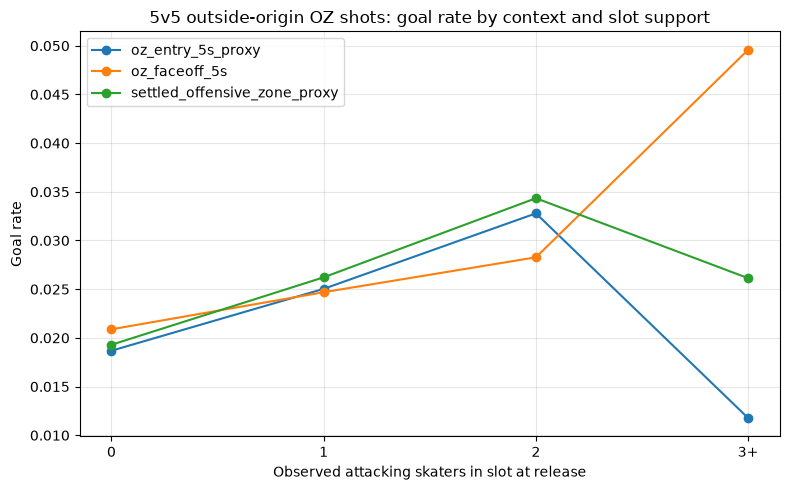

In [26]:
# Plot goal rate by observed attacking slot support across contexts

plt.figure(figsize=(8, 5))

for context in plot_contexts:
    context_plot = plot_table[
        plot_table["shot_context"].eq(context)
    ].sort_values("observed_attackers_slot_bin")

    plt.plot(
        context_plot["observed_attackers_slot_bin_str"],
        context_plot["goal_rate"],
        marker="o",
        label=context,
    )

plt.xlabel("Observed attacking skaters in slot at release")
plt.ylabel("Goal rate")
plt.title("5v5 outside-origin OZ shots: goal rate by context and slot support")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

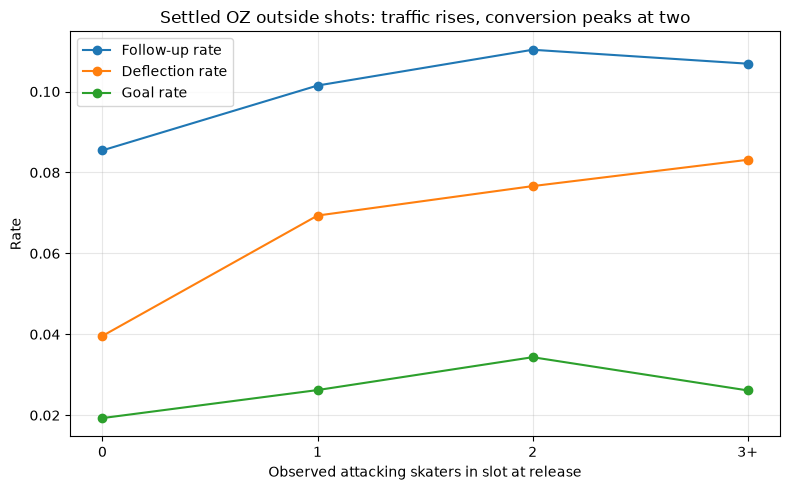

In [27]:
# Plot follow-up and deflection rates for settled offensive-zone possessions

settled_plot = plot_table[
    plot_table["shot_context"].eq("settled_offensive_zone_proxy")
].sort_values("observed_attackers_slot_bin")

plt.figure(figsize=(8, 5))

plt.plot(
    settled_plot["observed_attackers_slot_bin_str"],
    settled_plot["followup_rate"],
    marker="o",
    label="Follow-up rate",
)

plt.plot(
    settled_plot["observed_attackers_slot_bin_str"],
    settled_plot["deflection_rate"],
    marker="o",
    label="Deflection rate",
)

plt.plot(
    settled_plot["observed_attackers_slot_bin_str"],
    settled_plot["goal_rate"],
    marker="o",
    label="Goal rate",
)

plt.xlabel("Observed attacking skaters in slot at release")
plt.ylabel("Rate")
plt.title("Settled OZ outside shots: traffic rises, conversion peaks at two")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

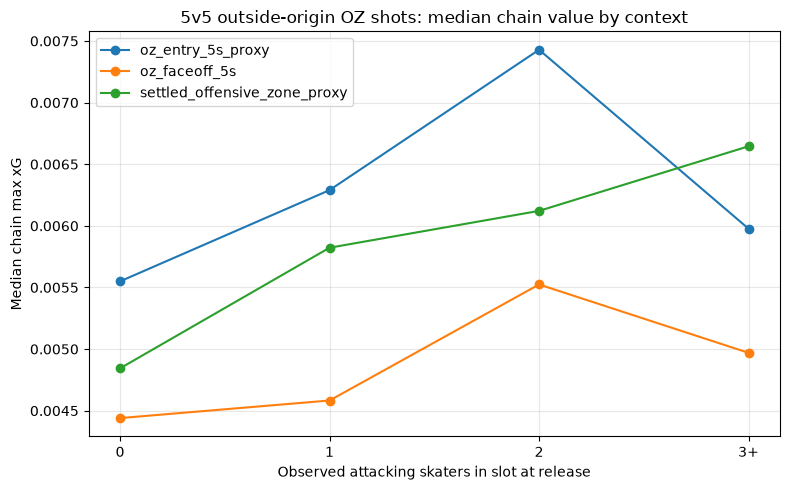

In [28]:
# Plot median chain value by observed attacking slot support across contexts

plt.figure(figsize=(8, 5))

for context in plot_contexts:
    context_plot = plot_table[
        plot_table["shot_context"].eq(context)
    ].sort_values("observed_attackers_slot_bin")

    plt.plot(
        context_plot["observed_attackers_slot_bin_str"],
        context_plot["median_chain_max_xg"],
        marker="o",
        label=context,
    )

plt.xlabel("Observed attacking skaters in slot at release")
plt.ylabel("Median chain max xG")
plt.title("5v5 outside-origin OZ shots: median chain value by context")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Final Notebook Validation

Run lightweight checks before committing the notebook.

This notebook is a diagnostic analysis notebook. It does not save a new processed dataset.

In [29]:
# Validate the final state of the context-stratified analysis notebook

final_notebook_validation = {
    "input_rows": len(df),
    "analysis_rows": len(analysis),
    "analysis_unique_chain_ids": analysis["chain_id"].nunique(),
    "analysis_duplicate_chain_ids": analysis.duplicated("chain_id").sum(),
    "behind_blue_line_rows_in_analysis": int(
        analysis["is_behind_offensive_blue_line_origin"].sum()
    ),
    "context_count_rows": len(analysis_context_counts),
    "summary_rows": len(summary_by_context_support),
    "threshold_diagnostic_rows": len(threshold_diagnostics),
    "overload_diagnostic_rows": len(overload_diagnostics),
    "context_pattern_summary_rows": len(context_pattern_summary),
    "context_interpretation_check_rows": len(context_interpretation_checks),
}

final_notebook_validation

{'input_rows': 48673,
 'analysis_rows': 21536,
 'analysis_unique_chain_ids': 21536,
 'analysis_duplicate_chain_ids': np.int64(0),
 'behind_blue_line_rows_in_analysis': 0,
 'context_count_rows': 4,
 'summary_rows': 16,
 'threshold_diagnostic_rows': 4,
 'overload_diagnostic_rows': 4,
 'context_pattern_summary_rows': 3,
 'context_interpretation_check_rows': 3}

In [30]:
# Assert expected final notebook validation values

expected_final_notebook_validation = {
    "input_rows": 48673,
    "analysis_rows": 21536,
    "analysis_unique_chain_ids": 21536,
    "analysis_duplicate_chain_ids": 0,
    "behind_blue_line_rows_in_analysis": 0,
    "context_pattern_summary_rows": 3,
    "context_interpretation_check_rows": 3,
}

for key, expected_value in expected_final_notebook_validation.items():
    actual_value = int(final_notebook_validation[key])
    assert actual_value == expected_value, (
        f"{key}: expected {expected_value}, got {actual_value}"
    )

print("Final notebook validation passed.")

Final notebook validation passed.
